In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
# ==================================================
# 1. Generowanie danych
# ==================================================

X, _ = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)


# Dodanie punktów odstających
generator = np.random.default_rng(42)

outliers = generator.uniform(
    low=[-1.5, -1.0],
    high=[2.5, 1.5],
    size=(25, 2)
)

X = np.vstack([X, outliers])

In [3]:
# ==================================================
# 2. Standaryzacja
# ==================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
# ==================================================
# 3. Model DBSCAN
# ==================================================

model = DBSCAN(
    eps=0.25,
    min_samples=6,
    metric="euclidean"
)

labels = model.fit_predict(X_scaled)


In [5]:
# ==================================================
# 4. Analiza wyniku
# ==================================================

number_of_clusters = len(set(labels) - {-1})
number_of_noise_points = np.sum(labels == -1)

print("Liczba wykrytych klastrów:", number_of_clusters)
print("Liczba punktów szumu:", number_of_noise_points)
print("Występujące etykiety:", np.unique(labels))


# Silhouette score liczymy bez punktów szumu
mask = labels != -1

if len(set(labels[mask])) >= 2:
    score = silhouette_score(
        X_scaled[mask],
        labels[mask]
    )

    print(f"Silhouette score: {score:.3f}")


Liczba wykrytych klastrów: 2
Liczba punktów szumu: 11
Występujące etykiety: [-1  0  1]
Silhouette score: 0.384


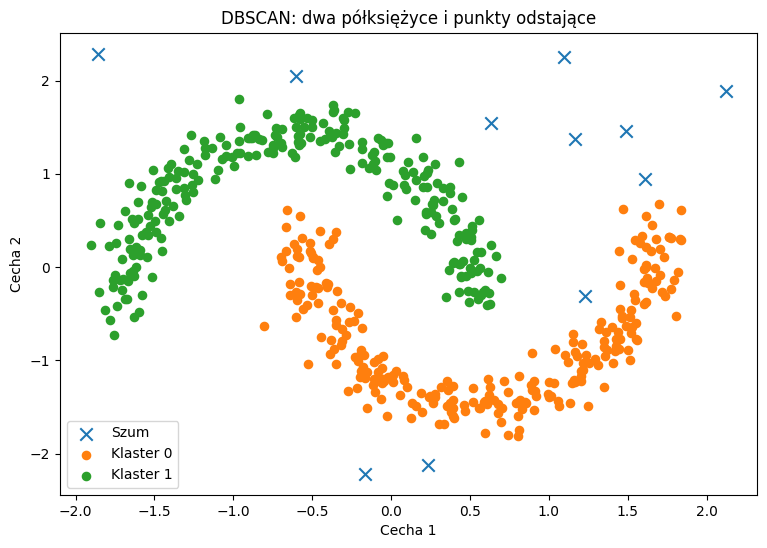

In [6]:
# ==================================================
# 5. Wizualizacja
# ==================================================

plt.figure(figsize=(9, 6))

for cluster_id in sorted(set(labels)):
    points = X_scaled[labels == cluster_id]

    if cluster_id == -1:
        plt.scatter(
            points[:, 0],
            points[:, 1],
            marker="x",
            s=80,
            label="Szum"
        )
    else:
        plt.scatter(
            points[:, 0],
            points[:, 1],
            s=35,
            label=f"Klaster {cluster_id}"
        )

plt.title("DBSCAN: dwa półksiężyce i punkty odstające")
plt.xlabel("Cecha 1")
plt.ylabel("Cecha 2")
plt.legend()
plt.show()